##### Import libraries

In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

import seaborn as sns
# sns.set_theme(style="whitegrid")

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
# Apply the default theme
sns.set_theme()
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
from scipy.stats import kurtosis
from sklearn.utils import resample

---

| Variable Name | Role | Type | Demographic | Description | Units | Missing Values |
|---|---|---|---|---|---|---|
| ID | ID | Integer | no | | | |
| X1 | Feature | Integer | | LIMIT_BAL | | no |
| X2 | Feature | Integer | Sex | SEX | | no |
| X3 | Feature | Integer | Education Level | EDUCATION | | no |
| X4 | Feature | Integer | Marital Status | MARRIAGE | | no |
| X5 | Feature | Integer | Age | AGE | | no |
| X6 | Feature | Integer | | PAY_0 | | no |
| X7 | Feature | Integer | | PAY_2 | | no |
| X8 | Feature | Integer | | PAY_3 | | no |
| X9 | Feature | Integer | | PAY_4 | | no |
| X10 | Feature | Integer | | PAY_5 | | no |
| X11 | Feature | Integer | | PAY_6 | | no |
| X12 | Feature | Integer | | BILL_AMT1 | | no |
| X13 | Feature | Integer | | BILL_AMT2 | | no |
| X14 | Feature | Integer | | BILL_AMT3 | | no |
| X15 | Feature | Integer | | BILL_AMT4 | | no |
| X16 | Feature | Integer | | BILL_AMT5 | | no |
| X17 | Feature | Integer | | BILL_AMT6 | | no |
| X18 | Feature | Integer | | PAY_AMT1 | | no |
| X19 | Feature | Integer | | PAY_AMT2 | | no |
| X20 | Feature | Integer | | PAY_AMT3 | | no |
| X21 | Feature | Integer | | PAY_AMT4 | | no |
| X22 | Feature | Integer | | PAY_AMT5 | | no |
| X23 | Feature | Integer | | PAY_AMT6 | | no |
| Y | Target | Binary | | default payment next month | | no |

* BILL - The last 6 months bills
* 

---

This data utilises a binary variable, default payment (Yes = 1, No = 0), as the response variable, together with 23 other variables:

- **X1**: Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.

- **X2**: Gender (1 = male; 2 = female).

- **X3**: Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).

- **X4**: Marital status (1 = married; 2 = single; 3 = others).

- **X5**: Age (year).

- **X6 - X11**: History of past payment. We tracked the past monthly payment records (from April to September, 2005) as follows:
  - X6 = the repayment status in September, 2005
  - X7 = the repayment status in August, 2005
  - ...
  - X11 = the repayment status in April, 2005
  - The measurement scale for the repayment status is: -2 = No payment due; -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; ...; 8 = payment delay for eight months; 9 = payment delay for nine months and above.

- **X12-X17**: Amount of bill statement (NT dollar).
  - X12 = amount of bill statement in September, 2005
  - X13 = amount of bill statement in August, 2005
  - ...
  - X17 = amount of bill statement in April, 2005

- **X18-X23**: Amount of previous payment (NT dollar).
  - X18 = amount paid in September, 2005
  - X19 = amount paid in August, 2005
  - ...
  - X23 = amount paid in April, 2005

---, 2005.


### 1.  DATA PROCESSING 

In [2]:
df = pd.read_excel('default of credit card clients.xls',engine='xlrd',header=1)

In [3]:
df['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

In [4]:
df.shape

(30000, 25)

In [5]:
df.head(3)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


In [6]:
df.tail(3)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
29997,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,30000,50000,1,2,1,46,0,0,0,0,0,0,47929,48905,49764,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


In [7]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

### Variable Identification and Typecasting

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [9]:
pd.concat([pd.DataFrame(df.dtypes).T,df.head(1)])

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1


All of the variables are set as integers, so we will need to change the data types.

In [10]:
# Converting columns to the correct data types 
df['default payment next month'] = df['default payment next month'].astype('category')
df['SEX'] = df['SEX'].astype('category')
df['MARRIAGE'] = df['MARRIAGE'].astype('category')
df['EDUCATION'] = df['EDUCATION'].astype('category')

# Payment columns

df['PAY_0'] = df['PAY_0'].astype('category')
df['PAY_2'] = df['PAY_2'].astype('category')
df['PAY_3'] = df['PAY_3'].astype('category')
df['PAY_4'] = df['PAY_4'].astype('category')
df['PAY_5'] = df['PAY_5'].astype('category')
df['PAY_6'] = df['PAY_6'].astype('category')

In [11]:
df.dtypes

ID                               int64
LIMIT_BAL                        int64
SEX                           category
EDUCATION                     category
MARRIAGE                      category
AGE                              int64
PAY_0                         category
PAY_2                         category
PAY_3                         category
PAY_4                         category
PAY_5                         category
PAY_6                         category
BILL_AMT1                        int64
BILL_AMT2                        int64
BILL_AMT3                        int64
BILL_AMT4                        int64
BILL_AMT5                        int64
BILL_AMT6                        int64
PAY_AMT1                         int64
PAY_AMT2                         int64
PAY_AMT3                         int64
PAY_AMT4                         int64
PAY_AMT5                         int64
PAY_AMT6                         int64
default payment next month    category
dtype: object

Null Values

In [12]:
# Check for Null Values
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [13]:
df.describe()

,ID,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,35.485500,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,8660.398374,129747.661567,9.217904,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,1.000000,10000.000000,21.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,28.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,15000.500000,140000.000000,34.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,22500.250000,240000.000000,41.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,30000.000000,1000000.000000,79.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


In [14]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [15]:
df = df.iloc[:,1:]

In [16]:
# Replace all of the 0 categories with 3's
df['MARRIAGE'] = df['MARRIAGE'].replace(0,3)

df['EDUCATION'] = df['EDUCATION'].replace([0,5,6],4)

## Exploratory Data Analysis

### Univariate Plots

View of the number of defaults according to gender

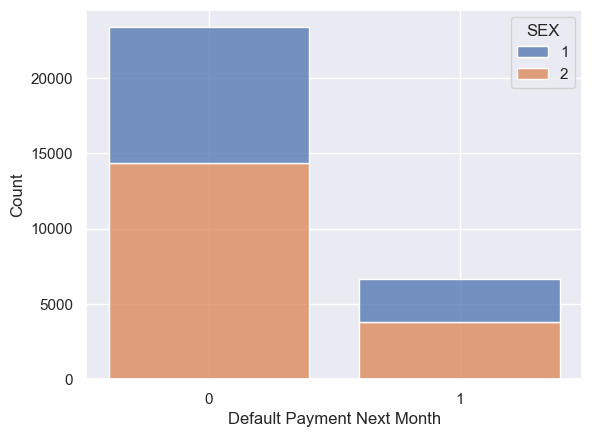

<Figure size 5000x4900 with 0 Axes>

In [17]:
sns.histplot(
    data=df,
    x="default payment next month",
    hue="SEX",
   multiple="stack",
    shrink=0.8,
    bins = [-0.5,0.5,1.5]
)
plt.xticks([0, 1])
plt.xlabel("Default Payment Next Month")
plt.ylabel("Count")
plt.figure(figsize=(50,49))
plt.show()


In [18]:
default_by_gender = df.groupby('SEX')['default payment next month'].value_counts().unstack(fill_value=0)
print('The proportion of defaults for Sex 1 (Male) is ',default_by_gender.iloc[0,1]/default_by_gender.sum(axis =1).iloc[0])
print('The proportion of defaults for Sex 2 (Female) is ',default_by_gender.iloc[1,1]/default_by_gender.sum(axis =1).iloc[1])

The proportion of defaults for Sex 1 (Male) is  0.2416722745625841
The proportion of defaults for Sex 2 (Female) is  0.20776280918727916


View of the number of defaults according to Marriage

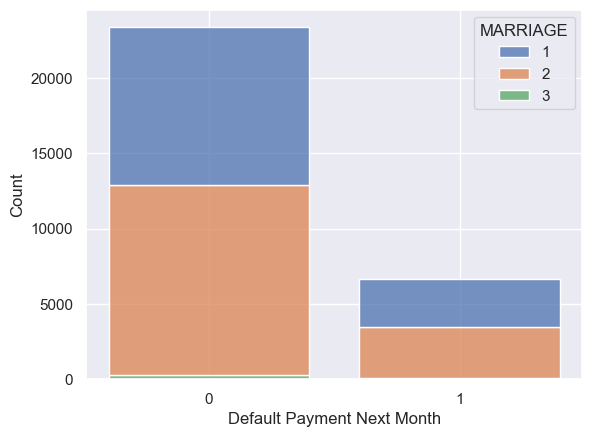

<Figure size 1000x4900 with 0 Axes>

In [19]:
sns.histplot(
    data=df,
    x="default payment next month",
    hue="MARRIAGE",
   multiple="stack",
    shrink=0.8,
    bins = [-0.5,0.5,1.5]
)
plt.xticks([0, 1])
plt.xlabel("Default Payment Next Month")
plt.ylabel("Count")
plt.figure(figsize=(10,49))
plt.show()


In [20]:
default_by_MARRIAGE = df.groupby('MARRIAGE')['default payment next month'].value_counts().unstack(fill_value=0)
print('The proportion of defaults for MARRIAGE 1 (Married) is ',default_by_MARRIAGE.iloc[0,1]/default_by_MARRIAGE.sum(axis =1).iloc[0])
print('The proportion of defaults for MARRIAGE 2 ( Single) is ',default_by_MARRIAGE.iloc[1,1]/default_by_MARRIAGE.sum(axis =1).iloc[1])
print('The proportion of defaults for MARRIAGE 3 (Others) is ',default_by_MARRIAGE.iloc[2,1]/default_by_MARRIAGE.sum(axis =1).iloc[2])

The proportion of defaults for MARRIAGE 1 (Married) is  0.23471703638626545
The proportion of defaults for MARRIAGE 2 ( Single) is  0.20928338762214985
The proportion of defaults for MARRIAGE 3 (Others) is  0.23607427055702918


View of the number of defaults according to Education

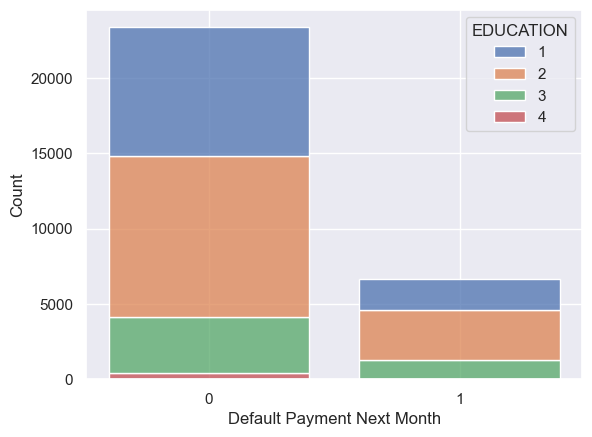

<Figure size 1000x4900 with 0 Axes>

In [21]:
sns.histplot(
    data=df,
    x="default payment next month",
    hue="EDUCATION",
   multiple="stack",
    shrink=0.8,
    bins = [-0.5,0.5,1.5]
)
plt.xticks([0, 1])
plt.xlabel("Default Payment Next Month")
plt.ylabel("Count")
plt.figure(figsize=(10,49))
plt.show()


In [22]:
default_by_EDUCATION= df.groupby('EDUCATION')['default payment next month'].value_counts().unstack(fill_value=0)
print('The proportion of defaults for EDUCATION 1 (graduate school) is ',default_by_EDUCATION.iloc[0,1]/default_by_EDUCATION.sum(axis =1).iloc[0])
print('The proportion of defaults for EDUCATION 2 (university) is ',default_by_EDUCATION.iloc[1,1]/default_by_EDUCATION.sum(axis =1).iloc[1])
print('The proportion of defaults for EDUCATION 3 (high school) is ',default_by_EDUCATION.iloc[2,1]/default_by_EDUCATION.sum(axis =1).iloc[2])
print('The proportion of defaults for EDUCATION 4 (Others) is ',default_by_EDUCATION.iloc[3,1]/default_by_EDUCATION.sum(axis =1).iloc[3])

The proportion of defaults for EDUCATION 1 (graduate school) is  0.19234766178554558
The proportion of defaults for EDUCATION 2 (university) is  0.23734853884533144
The proportion of defaults for EDUCATION 3 (high school) is  0.2515761643278422
The proportion of defaults for EDUCATION 4 (Others) is  0.07051282051282051


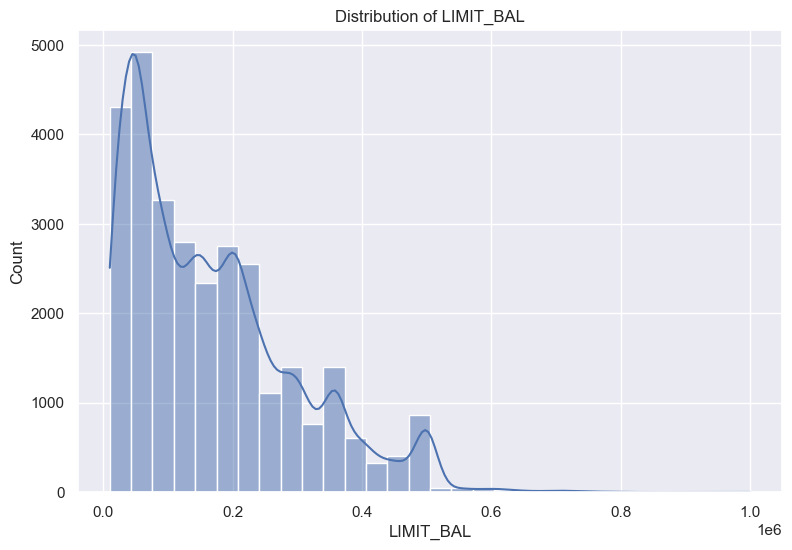

In [23]:
# Setting up the figure size and layout for multiple plots
plt.figure(figsize=(20, 15))
plt.subplots_adjust(hspace=0.5)

# Distribution of Age
plt.subplot(2, 2, 1)
sns.histplot(df['LIMIT_BAL'], bins=30, kde=True)
plt.title('Distribution of LIMIT_BAL')
plt.show()

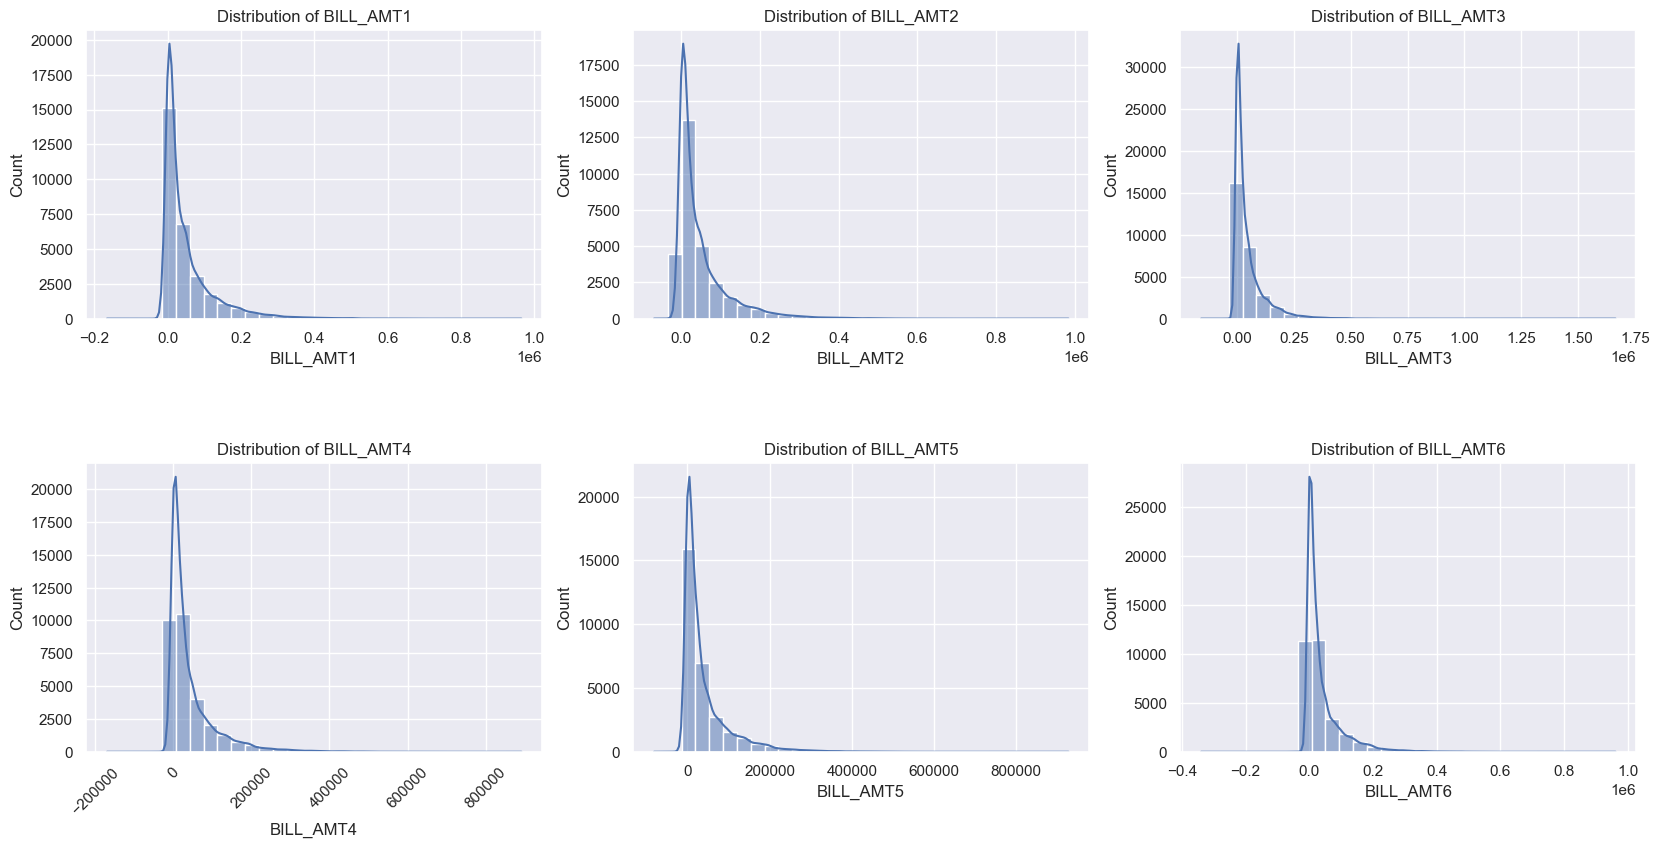

In [24]:
# Setting up the figure size and layout for multiple plots
plt.figure(figsize=(20, 15))
plt.subplots_adjust(hspace=0.5)

# Distribution of Age
plt.subplot(3, 3, 1)
sns.histplot(df['BILL_AMT1'], bins=30, kde=True)
plt.title('Distribution of BILL_AMT1')

# Distribution of Current Balance
plt.subplot(3, 3, 2)
sns.histplot(df['BILL_AMT2'], bins=30, kde=True)  # Limiting to a smaller range for clarity
plt.title('Distribution of BILL_AMT2')

# Distribution of Gender
plt.subplot(3, 3, 3)
sns.histplot(df['BILL_AMT3'], bins=30, kde=True) 
plt.title('Distribution of BILL_AMT3')

# Distribution of Occupation
plt.subplot(3, 3, 4)
sns.histplot(df['BILL_AMT4'], bins=30, kde=True) 
plt.xticks(rotation=45)
plt.title('Distribution of BILL_AMT4')

plt.subplot(3, 3, 5)
sns.histplot(df['BILL_AMT5'], bins=30, kde=True) 
plt.title('Distribution of BILL_AMT5')


plt.subplot(3, 3, 6)
sns.histplot(df['BILL_AMT6'], bins=30, kde=True) 
plt.title('Distribution of BILL_AMT6')

plt.show()

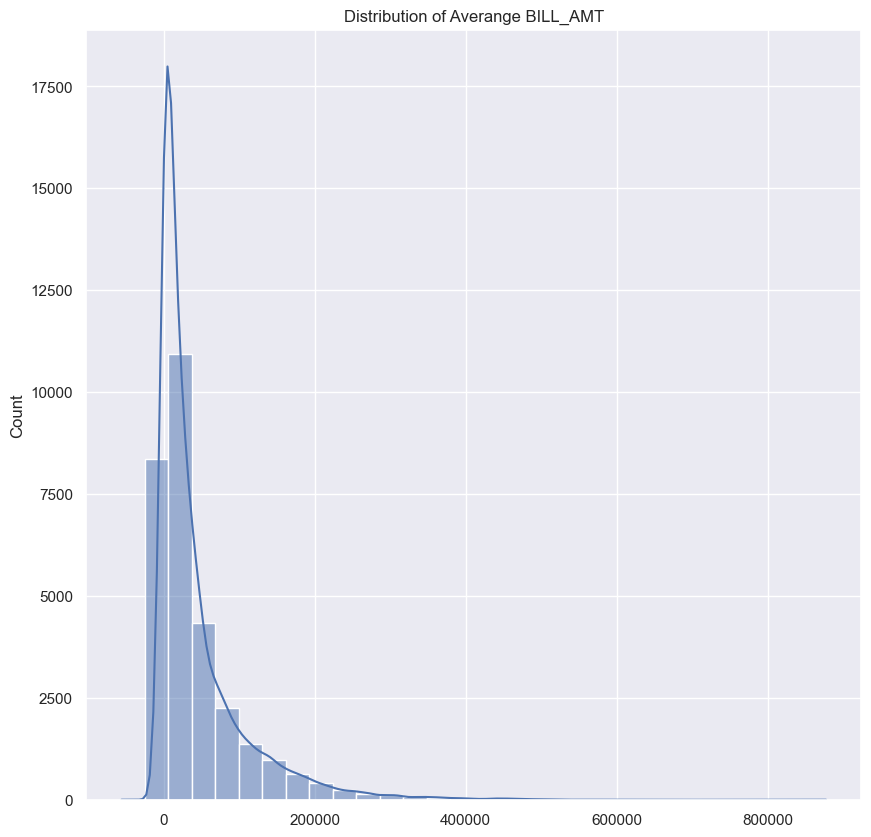

In [25]:
# Setting up the figure size and layout for multiple plots
plt.figure(figsize=(10, 10))
plt.subplots_adjust(hspace=0.5)
sns.histplot(df.loc[:,['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']].mean(axis =1), bins=30, kde=True) 
plt.title('Distribution of Averange BILL_AMT')
plt.show()

### Bivariate Plots: 2 Numeric Variables

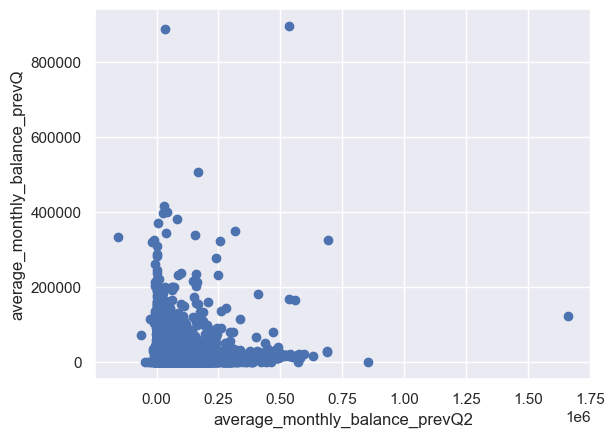

In [26]:
plt.scatter(df['BILL_AMT3'], df['PAY_AMT3'], marker='o')
plt.xlabel('average_monthly_balance_prevQ2')
plt.ylabel('average_monthly_balance_prevQ');

### Correlation Analysis

In [27]:
corr_mat = df.corr(numeric_only=True).round(2)
corr_mat

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
LIMIT_BAL,1.00,0.14,0.29,0.28,0.28,0.29,0.30,0.29,0.20,0.18,0.21,0.20,0.22,0.22
AGE,0.14,1.00,0.06,0.05,0.05,0.05,0.05,0.05,0.03,0.02,0.03,0.02,0.02,0.02
BILL_AMT1,0.29,0.06,1.00,0.95,0.89,0.86,0.83,0.80,0.14,0.10,0.16,0.16,0.17,0.18
BILL_AMT2,0.28,0.05,0.95,1.00,0.93,0.89,0.86,0.83,0.28,0.10,0.15,0.15,0.16,0.17
BILL_AMT3,0.28,0.05,0.89,0.93,1.00,0.92,0.88,0.85,0.24,0.32,0.13,0.14,0.18,0.18
BILL_AMT4,0.29,0.05,0.86,0.89,0.92,1.00,0.94,0.90,0.23,0.21,0.30,0.13,0.16,0.18
BILL_AMT5,0.30,0.05,0.83,0.86,0.88,0.94,1.00,0.95,0.22,0.18,0.25,0.29,0.14,0.16
BILL_AMT6,0.29,0.05,0.80,0.83,0.85,0.90,0.95,1.00,0.20,0.17,0.23,0.25,0.31,0.12
PAY_AMT1,0.20,0.03,0.14,0.28,0.24,0.23,0.22,0.20,1.00,0.29,0.25,0.20,0.15,0.19
PAY_AMT2,0.18,0.02,0.10,0.10,0.32,0.21,0.18,0.17,0.29,1.00,0.24,0.18,0.18,0.16


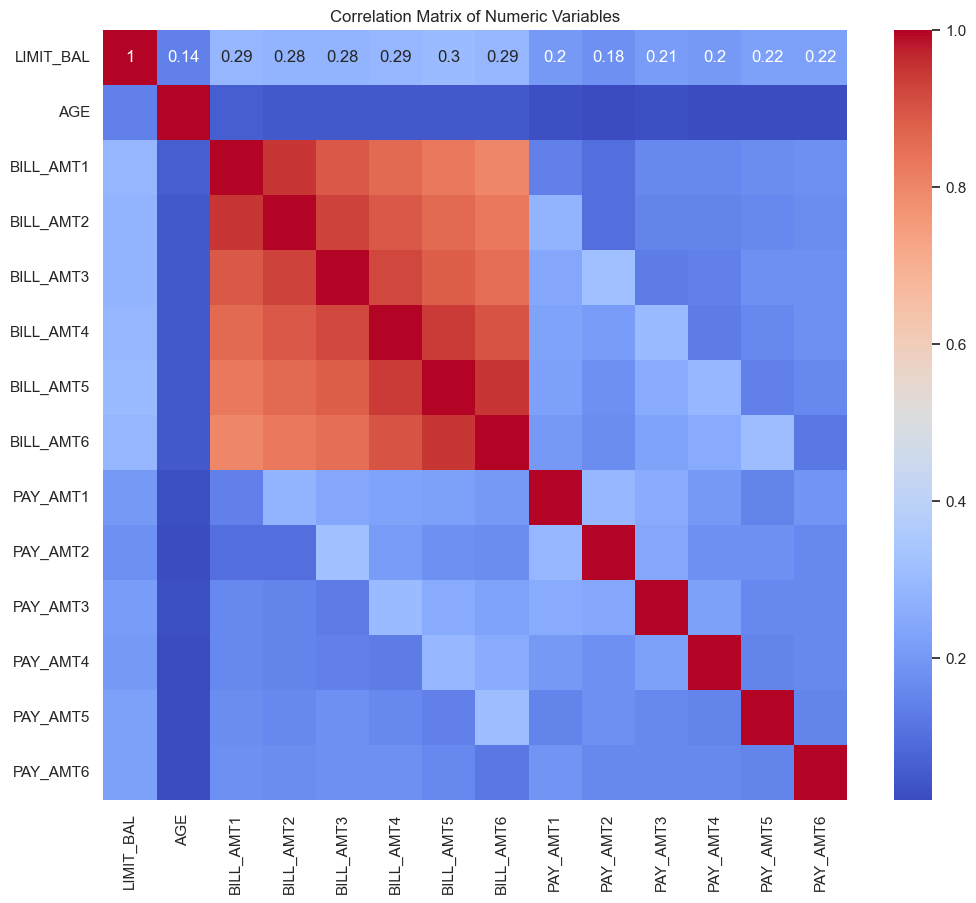

In [28]:
plt.figure(figsize=(12,10))
sns.heatmap(corr_mat, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Variables")
plt.show()

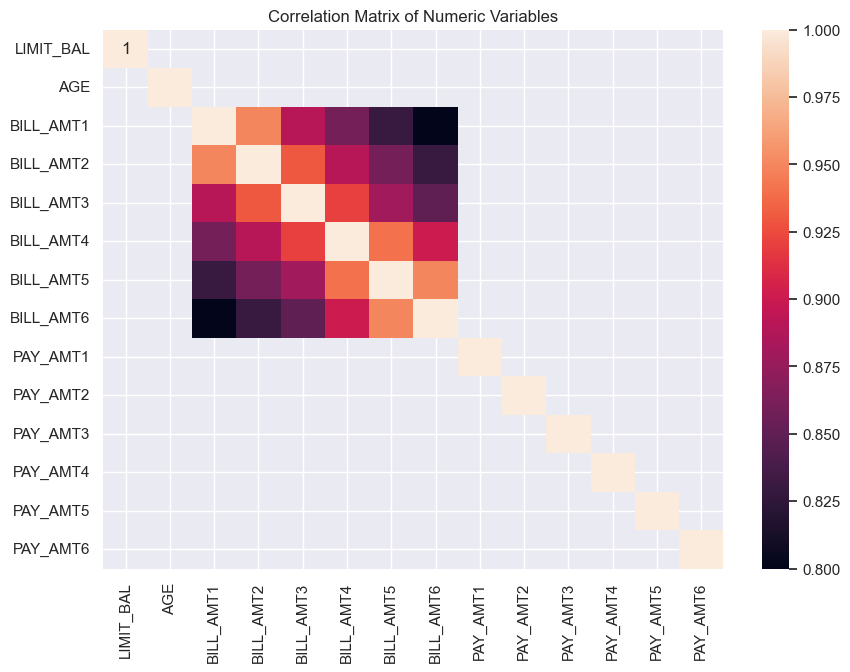

In [29]:
# Find those correlations which are greater than 0.5
corr_mat1 = corr_mat[np.abs(corr_mat) > 0.5]
plt.figure(figsize=(10,7))
sns.heatmap(corr_mat1, annot=True)
plt.title("Correlation Matrix of Numeric Variables")
plt.show()

### Splitting dataset

- We'll divide the dataset into two parts:
  - A training set (80%) for building the model using statistical and machine learning techniques.
  - A test set (20%) to make predictions and assess the model's performance.

In [30]:
# Remove 'SeriousDlqin2yrs' column
data = df.drop(columns=['default payment next month'], axis=1)

y = df['default payment next month']

In [31]:
from sklearn.model_selection import train_test_split

# Split data into train and test sets
df_test, df_train, y_test, y_train = train_test_split(data, y, test_size=0.8, random_state=42, stratify=y)

# Display the shapes of the resulting sets
df_test.shape, df_train.shape

((6000, 23), (24000, 23))

In [32]:
# Combine features and target in 'train' DataFrame, and check its shape
train = pd.concat([df_train, y_train], axis=1)
train.shape

(24000, 24)

In [33]:
# Combine test features and target, and check its shape
test = pd.concat([df_test, y_test], axis=1)
test.shape

(6000, 24)

In [34]:
cols_for_stats = train.select_dtypes(include=['int64']).columns

In [35]:
# Initialize lists for skewness and kurtosis
skewness = []
kurt = []

# Calculate skewness and kurtosis for specified columns
for column in cols_for_stats:
    skewness.append(skew(train[train[column].notnull()][column]))
    kurt.append(kurtosis(train[train[column].notnull()][column]))

# Create a DataFrame with skewness and kurtosis, indexed by column names
stats = pd.DataFrame({'Skewness': skewness, 'Kurtosis': kurt}, index=cols_for_stats)

# Sort the DataFrame by 'Skewness' in descending order
stats.sort_values(by=['Skewness'], ascending=False)


,Skewness,Kurtosis
PAY_AMT2,31.348142,1761.299726
PAY_AMT3,15.559141,494.701912
PAY_AMT4,11.930833,231.552594
PAY_AMT5,11.462196,193.285477
PAY_AMT6,11.129604,183.700829
PAY_AMT1,10.565609,162.939756
BILL_AMT3,3.187408,22.321357
BILL_AMT5,2.912187,12.980473
BILL_AMT6,2.889708,13.073777
BILL_AMT4,2.835613,11.579585


* Data distribution in the columns are highly right skewed with very high kurtosis value showing extreme outliers in those columns
* Except age which is little normally distributed

* The PAY_AMT variables are extremely skewed. This is due to most customers paying small or zero amounts and a small elite pay very large amonts.

In [36]:
import pandas as pd
import numpy as np

def treat_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Winsorise
    df[column] = np.where(df[column] < lower, lower,
                    np.where(df[column] > upper, upper, df[column]))
    return df


In [37]:
for col in ['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']:
    train_new = treat_outliers_iqr(train, col)

In [38]:
train_new.shape

(24000, 24)

In [39]:
# Initialize lists for skewness and kurtosis
skewness = []
kurt = []

# Calculate skewness and kurtosis for specified columns
for column in cols_for_stats:
    skewness.append(skew(train_new[train_new[column].notnull()][column]))
    kurt.append(kurtosis(train_new[train_new[column].notnull()][column]))

# Create a DataFrame with skewness and kurtosis, indexed by column names
stats = pd.DataFrame({'Skewness': skewness, 'Kurtosis': kurt}, index=cols_for_stats)

# Sort the DataFrame by 'Skewness' in descending order
stats.sort_values(by=['Skewness'], ascending=False)


,Skewness,Kurtosis
PAY_AMT6,1.212029,0.266085
PAY_AMT3,1.201287,0.245780
BILL_AMT6,1.199881,0.157002
BILL_AMT1,1.197417,0.207921
BILL_AMT2,1.191828,0.195473
BILL_AMT3,1.185140,0.161043
BILL_AMT5,1.183234,0.107717
BILL_AMT4,1.180128,0.124343
PAY_AMT5,1.179358,0.179479
PAY_AMT4,1.178921,0.160969


## Feature Engineering

In [40]:
train_new.reset_index(drop=True,inplace=True)

In [41]:
import pandas as pd
import numpy as np

def create_aggregated_features(df):
    """
    Create meaningful aggregate features that reduce complexity
    while preserving important relationships.
    Safe against categorical types and missing values.
    """
    df_new = df.copy()

    # ==== FORCE NUMERIC WHERE REQUIRED (prevents categorical max errors) ====
    pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
    payamt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

    df_new[pay_cols] = df_new[pay_cols].apply(pd.to_numeric, errors="coerce")
    df_new[bill_cols] = df_new[bill_cols].apply(pd.to_numeric, errors="coerce")
    df_new[payamt_cols] = df_new[payamt_cols].apply(pd.to_numeric, errors="coerce")

    # ===== DEMOGRAPHIC FEATURES (Root nodes) =====
    df_new['SEX'] = df['SEX']
    df_new['EDUCATION'] = df['EDUCATION']
    df_new['MARRIAGE'] = df['MARRIAGE']

    # Discretize AGE
    df_new['AGE_GROUP'] = pd.cut(
        df['AGE'],
        bins=[0, 30, 40, 50, 100],
        labels=['Young', 'Middle', 'Senior', 'Elderly']
    )

    # ===== CREDIT LIMIT =====
    df_new['CREDIT_LIMIT_CAT'] = pd.cut(
        df['LIMIT_BAL'],
        bins=[0, 50000, 200000, 500000, 1000000],
        labels=['Low', 'Medium', 'High', 'VeryHigh']
    )

    # ===== PAYMENT HISTORY AGGREGATES =====
    df_new['RECENT_PAY_STATUS'] = df_new[['PAY_0', 'PAY_2']].max(axis=1)

    df_new['HISTORICAL_PAY_STATUS'] = df_new[
        ['PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
    ].max(axis=1)

    df_new['TIMES_PAID_DULY'] = (df_new[pay_cols] <= 0).sum(axis=1)

    df_new['MAX_DELAY_EVER'] = df_new[pay_cols].max(axis=1)

    df_new['PAYMENT_TREND'] = (
        df_new['PAY_0'] - df_new['PAY_6']
    ).apply(lambda x: 'Improving' if x < -1 else ('Worsening' if x > 1 else 'Stable'))

    # ===== BILL AMOUNT AGGREGATES =====
    df_new['AVG_BILL'] = df_new[bill_cols].mean(axis=1)

    df_new['RECENT_BILL'] = df_new['BILL_AMT1']

    df_new['BILL_TREND'] = (
        df_new['BILL_AMT1'] - df_new['BILL_AMT6']
    ).apply(lambda x: 'Increasing' if x > 10000 else ('Decreasing' if x < -10000 else 'Stable'))

    df_new['BILL_VOLATILITY'] = df_new[bill_cols].std(axis=1)

    df_new['AVG_BILL_CAT'] = pd.qcut(
        df_new['AVG_BILL'],
        q=4,
        labels=['Low', 'Medium', 'High', 'VeryHigh'],
        duplicates='drop'
    )

    # ===== PAYMENT AMOUNT AGGREGATES =====
    df_new['AVG_PAYMENT'] = df_new[payamt_cols].mean(axis=1)

    df_new['RECENT_PAYMENT'] = df_new['PAY_AMT1']

    df_new['PAYMENT_CONSISTENCY'] = (df_new[payamt_cols] > 0).sum(axis=1)

    # ===== RATIO FEATURES =====

    # Utilization
    df_new['UTILIZATION_RATE'] = (
        df_new['AVG_BILL'] / df_new['LIMIT_BAL']
    ).clip(0, 2)

    df_new['UTILIZATION_CAT'] = pd.cut(
        df_new['UTILIZATION_RATE'],
        bins=[0, 0.3, 0.6, 0.9, 10],
        labels=['Low', 'Medium', 'High', 'Overlimit']
    )

    # Payment-to-bill ratio
    df_new['PAYMENT_TO_BILL_RATIO'] = np.where(
        df_new['AVG_BILL'] > 0,
        (df_new['AVG_PAYMENT'] / df_new['AVG_BILL']).clip(0, 2),
        1.0
    )

    df_new['PAYMENT_ADEQUACY'] = pd.cut(
        df_new['PAYMENT_TO_BILL_RATIO'],
        bins=[0, 0.1, 0.5, 0.9, 10],
        labels=['VeryLow', 'Low', 'Adequate', 'Good']
    )

    # Financial stress indicator
    df_new['FINANCIAL_STRESS'] = (
        (df_new['UTILIZATION_RATE'] > 0.8).astype(int)
        + (df_new['PAYMENT_TO_BILL_RATIO'] < 0.3).astype(int)
        + (df_new['MAX_DELAY_EVER'] > 2).astype(int)
    )

    # # ===== TARGET =====
    # df_new['DEFAULT'] = df['default payment next month']

    return df_new
train_N = create_aggregated_features(train_new)
test_N = create_aggregated_features(test)

In [42]:
train_N.shape

(24000, 44)

In [43]:
train_N = train_N.dropna()
test_N = test_N.dropna()

In [44]:
dataset = [train_N, test_N]

In [45]:
train_N.shape

(22709, 44)

In [46]:
test_N.shape

(5659, 44)

#### Tackling Class Imbalance Problem using:

- Upsampling the minority class(default rate)
- Downsampling the majority class(non defaulters)
- SMOTE - synthethic sampling

#### Upsampling

In [47]:
df_majority = train_N[train_N['default payment next month'] == 0]


df_minority = train_N[train_N['default payment next month'] == 1]


In [48]:
train_N['default payment next month'].value_counts()

default payment next month
0    17869
1     4840
Name: count, dtype: int64

In [49]:
train_N =train_N.dropna()

In [50]:
def freq_distn(df):
    freq_dist = df["default payment next month"].value_counts().to_frame()
    freq_dist.reset_index(inplace=True) # reset index
    freq_dist.columns = [   "default payment next month"   , 'Cnt_Obs'] # rename columns
    freq_dist["Proportions"] = freq_dist['Cnt_Obs'] / sum(freq_dist['Cnt_Obs'])
    return freq_dist

In [51]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42, sampling_strategy=0.4)

rus.fit(train_N, train_N['default payment next month'])
x_rus, y_rus = rus.fit_resample(train_N, train_N['default payment next month'])

freq_distn(x_rus)

,default payment next month,Cnt_Obs,Proportions
0,0,12100,0.714286
1,1,4840,0.285714


In [52]:
x_rus.shape

(16940, 44)

In [53]:
y_rus

6532     0
3653     0
11876    0
12918    0
21846    0
        ..
23983    1
23985    1
23987    1
23990    1
23991    1
Name: default payment next month, Length: 16940, dtype: category
Categories (2, int64): [0, 1]

---

In [54]:
train_N.shape

(22709, 44)

In [55]:
nominal_cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE','AGE_GROUP','CREDIT_LIMIT_CAT','PAYMENT_TREND']

ordinal_cat_cols = ['PAY_0', 'PAY_2','PAY_3','PAY_4',
                    'PAY_5','PAY_6','RECENT_PAY_STATUS','HISTORICAL_PAY_STATUS',
                    'TIMES_PAID_DULY','MAX_DELAY_EVER','PAYMENT_TREND','PAYMENT_TREND',
                    'BILL_TREND','AVG_BILL_CAT','PAYMENT_CONSISTENCY','UTILIZATION_CAT','PAYMENT_ADEQUACY','FINANCIAL_STRESS']

numeric_cols = ['LIMIT_BAL', 'AGE','PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6','AVG_BILL', 'RECENT_BILL',
        'BILL_VOLATILITY', 'AVG_PAYMENT',
       'RECENT_PAYMENT', 'UTILIZATION_RATE',
        'PAYMENT_TO_BILL_RATIO']

In [56]:
len(nominal_cat_cols)+len(ordinal_cat_cols)+len(numeric_cols)

39

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [58]:
categorical_transformer = Pipeline(steps=[
                                          ("onehot", OneHotEncoder(sparse_output=False,
                                                                   drop='first',
                                                                   handle_unknown="ignore").set_output(transform="pandas"))
                                          ])
categorical_transformer

Pipeline(steps=[('onehot',
                 OneHotEncoder(drop='first', handle_unknown='ignore',
                               sparse_output=False))])

## Define Numeric Transformer Pipeline

Consists of the series of steps needed to tranform the numeric features. This includes:

- Standard Scaler to scale the numeric features

In [59]:
numeric_transformer = Pipeline(steps=[
                                      ("scaler", StandardScaler().set_output(transform="pandas"))
                                      ])

numeric_transformer

Pipeline(steps=[('scaler', StandardScaler())])

## Define Column Transformer Pipeline for preprocessing

Consists of the series of steps needed to tranform all the features in sequence

- Numeric Transfomer defined earlier
- Categorical Transfomer defined earlier for Nominal Categorical data
- Passthrough (do nothing) for Ordinal Categorical data

In [60]:
from sklearn.compose import ColumnTransformer

In [61]:
preprocessor = ColumnTransformer(transformers=[
                                               ("ord_cat", 'passthrough', ordinal_cat_cols),
                                               ("num", numeric_transformer, numeric_cols),
                                               ("nom_cat", categorical_transformer, nominal_cat_cols),
                                               ]).set_output(transform="pandas")
preprocessor

ColumnTransformer(transformers=[('ord_cat', 'passthrough',
                                 ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
                                  'PAY_6', 'RECENT_PAY_STATUS',
                                  'HISTORICAL_PAY_STATUS', 'TIMES_PAID_DULY',
                                  'MAX_DELAY_EVER', 'PAYMENT_TREND',
                                  'PAYMENT_TREND', 'BILL_TREND', 'AVG_BILL_CAT',
                                  'PAYMENT_CONSISTENCY', 'UTILIZATION_CAT',
                                  'PAYMENT_ADEQUACY', 'FINANCIAL_STRESS']),
                                ('num',
                                 Pipeline(steps=[('...
                                  'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5',
                                  'PAY_AMT6', 'AVG_BILL', 'RECENT_BILL',
                                  'BILL_VOLATILITY', 'AVG_PAYMENT',
                                  'RECENT_PAYMENT', 'UTILIZATION_RATE',
                                  'PAYMENT_TO_BILL_RATIO']),
                                ('nom_cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE_GROUP',
                                  'CREDIT_LIMIT_CAT', 'PAYMENT_TREND'])])

In [62]:
X_train =  x_rus.loc[:,['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6','PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
 'AGE_GROUP', 'CREDIT_LIMIT_CAT',
       'RECENT_PAY_STATUS', 'HISTORICAL_PAY_STATUS', 'TIMES_PAID_DULY',
       'MAX_DELAY_EVER', 'PAYMENT_TREND', 'AVG_BILL', 'RECENT_BILL',
       'BILL_TREND', 'BILL_VOLATILITY', 'AVG_BILL_CAT', 'AVG_PAYMENT',
       'RECENT_PAYMENT', 'PAYMENT_CONSISTENCY', 'UTILIZATION_RATE',
       'UTILIZATION_CAT', 'PAYMENT_TO_BILL_RATIO', 'PAYMENT_ADEQUACY',
       'FINANCIAL_STRESS']]
Y_train = x_rus.loc[:,['default payment next month']]

In [63]:
test.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [64]:
X_test=  test_N.loc[:,['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6','PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
 'AGE_GROUP', 'CREDIT_LIMIT_CAT',
       'RECENT_PAY_STATUS', 'HISTORICAL_PAY_STATUS', 'TIMES_PAID_DULY',
       'MAX_DELAY_EVER', 'PAYMENT_TREND', 'AVG_BILL', 'RECENT_BILL',
       'BILL_TREND', 'BILL_VOLATILITY', 'AVG_BILL_CAT', 'AVG_PAYMENT',
       'RECENT_PAYMENT', 'PAYMENT_CONSISTENCY', 'UTILIZATION_RATE',
       'UTILIZATION_CAT', 'PAYMENT_TO_BILL_RATIO', 'PAYMENT_ADEQUACY',
       'FINANCIAL_STRESS']]
y_test = test_N.loc[:,['default payment next month']]

In [65]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X_train['PAYMENT_TREND'] = le.fit_transform(X_train['PAYMENT_TREND'])
X_train['BILL_TREND'] = le.fit_transform(X_train['BILL_TREND'])
X_train['PAYMENT_ADEQUACY'] = le.fit_transform(X_train['PAYMENT_ADEQUACY'])
X_train['UTILIZATION_CAT'] = le.fit_transform(X_train['UTILIZATION_CAT'])
X_train['AVG_BILL_CAT'] = le.fit_transform(X_train['AVG_BILL_CAT'])
X_train['AGE_GROUP'] = le.fit_transform(X_train['AGE_GROUP'])
X_train['CREDIT_LIMIT_CAT'] = le.fit_transform(X_train['CREDIT_LIMIT_CAT'])


X_test['PAYMENT_TREND'] = le.fit_transform(X_test['PAYMENT_TREND'])
X_test['BILL_TREND'] = le.fit_transform(X_test['BILL_TREND'])
X_test['PAYMENT_ADEQUACY'] = le.fit_transform(X_test['PAYMENT_ADEQUACY'])
X_test['UTILIZATION_CAT'] = le.fit_transform(X_test['UTILIZATION_CAT'])
X_test['AVG_BILL_CAT'] = le.fit_transform(X_test['AVG_BILL_CAT'])
X_test['AGE_GROUP'] = le.fit_transform(X_test['AGE_GROUP'])
X_test['CREDIT_LIMIT_CAT'] = le.fit_transform(X_test['CREDIT_LIMIT_CAT'])

In [66]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.fit_transform(X_test)
y_train =y_rus

In [67]:
X_test.shape

(5659, 47)

In [68]:
len(y_test)

5659

In [69]:
# Add this before model.fit()
print("Checking for duplicate columns...")
print(f"Total columns: {len(X_train.columns)}")
print(f"Unique columns: {len(X_train.columns.unique())}")

# Find duplicates
duplicates = X_train.columns[X_train.columns.duplicated()].unique()
if len(duplicates) > 0:
    print(f"Duplicate columns found: {duplicates}")
    
    # Remove duplicates (keeps first occurrence)
    X_train = X_train.loc[:, ~X_train.columns.duplicated()]
    X_test = X_test.loc[:, ~X_test.columns.duplicated()]
    
    print(f"After removing duplicates: {len(X_train.columns)} columns")

Checking for duplicate columns...
Total columns: 47
Unique columns: 46
Duplicate columns found: Index(['ord_cat__PAYMENT_TREND'], dtype='object')
After removing duplicates: 46 columns


---

Training CatBoost model...
0:	learn: 0.7839433	test: 0.8172822	best: 0.8172822 (0)	total: 63.4ms	remaining: 1m 3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8262943983
bestIteration = 29

Shrink model to first 30 iterations.

MODEL EVALUATION

Accuracy: 0.8263

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      4453
           1       0.63      0.44      0.52      1206

    accuracy                           0.83      5659
   macro avg       0.75      0.68      0.71      5659
weighted avg       0.81      0.83      0.81      5659


Prediction probabilities shape: (5659, 2)

FEATURE IMPORTANCE

Top 10 Most Important Features:
                   feature  importance
            ord_cat__PAY_0   17.325924
ord_cat__RECENT_PAY_STATUS   12.508293
  ord_cat__TIMES_PAID_DULY    9.215553
   ord_cat__MAX_DELAY_EVER    6.090517
            num__LIMIT_BAL    5.751350
      num__BILL_VOLATILITY    5.2

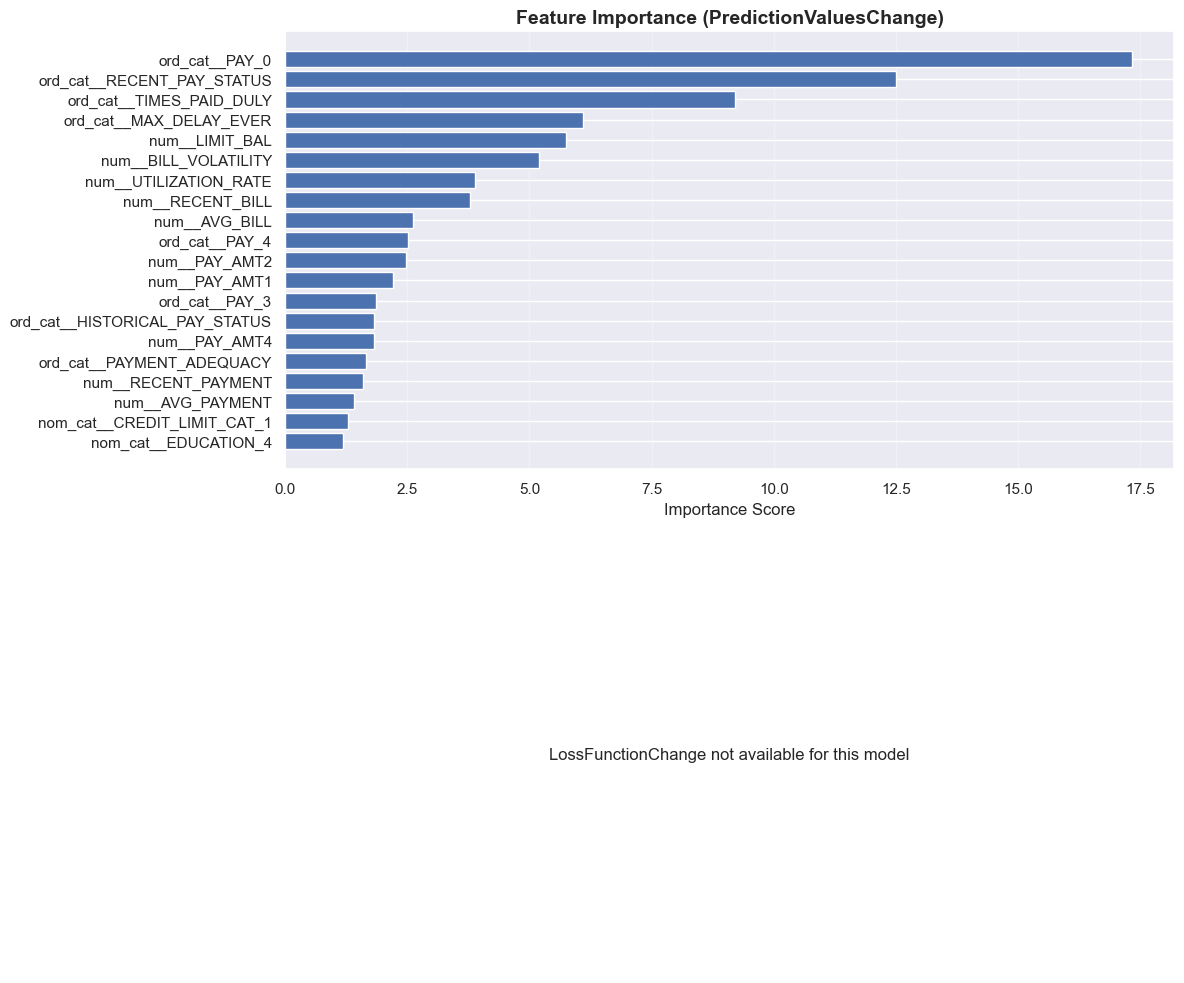


✓ Feature importance plot saved as 'catboost_feature_importance.png'


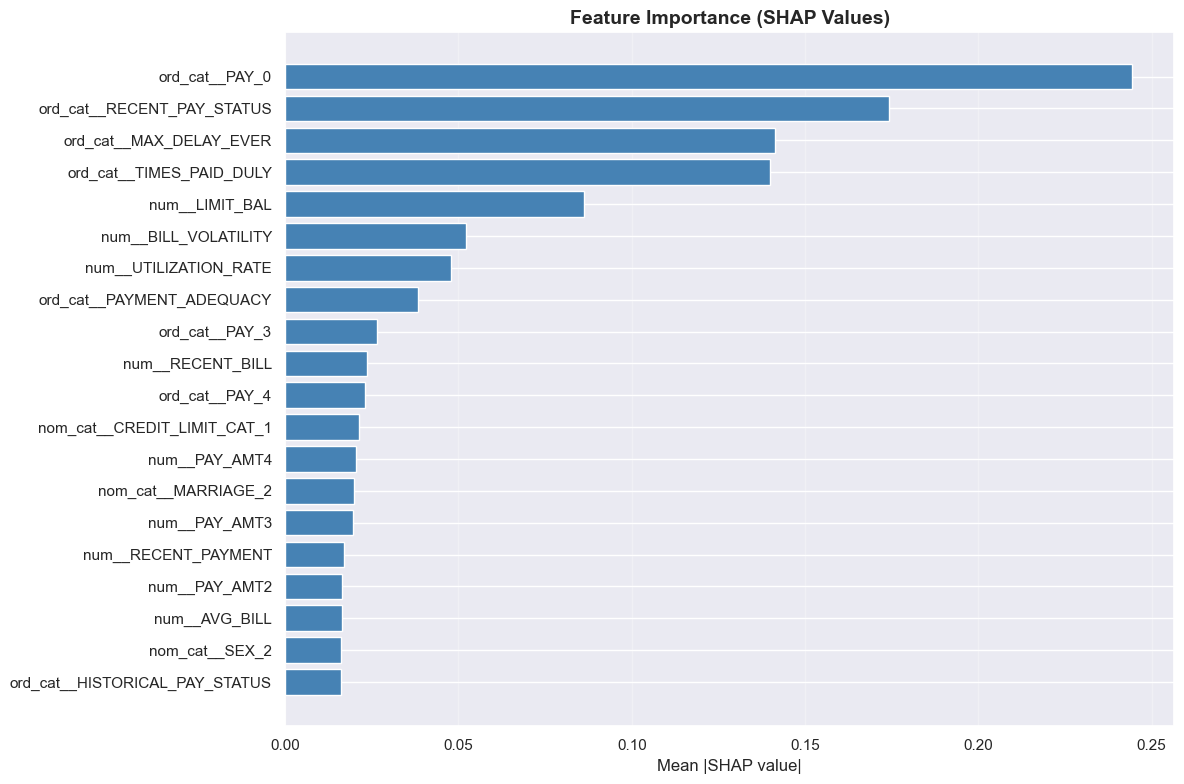

✓ SHAP importance plot saved as 'catboost_shap_importance.png'

Top 10 Features by SHAP Importance:
                   feature  mean_abs_shap
            ord_cat__PAY_0       0.244240
ord_cat__RECENT_PAY_STATUS       0.174119
   ord_cat__MAX_DELAY_EVER       0.141389
  ord_cat__TIMES_PAID_DULY       0.139959
            num__LIMIT_BAL       0.086160
      num__BILL_VOLATILITY       0.052143
     num__UTILIZATION_RATE       0.047877
 ord_cat__PAYMENT_ADEQUACY       0.038460
            ord_cat__PAY_3       0.026510
          num__RECENT_BILL       0.023738

✓ Model saved as 'catboost_model.cbm'

COMPLETE!


In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score


# ==========================================
# STEP 2: Identify categorical features (if any)
# ==========================================
# List your categorical feature names here
categorical_features = []  # e.g., ['category_col1', 'category_col2']

# ==========================================
# STEP 3: Choose model type and set parameters
# ==========================================
# For CLASSIFICATION
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',  # or 'MultiClass' for multi-class
    eval_metric='Accuracy',
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50
)

# For REGRESSION (uncomment if needed)
# model = CatBoostRegressor(
#     iterations=1000,
#     learning_rate=0.1,
#     depth=6,
#     loss_function='RMSE',
#     eval_metric='RMSE',
#     random_seed=42,
#     verbose=100,
#     early_stopping_rounds=50
# )

# ==========================================
# STEP 4: Train the model
# ==========================================
print("Training CatBoost model...")
model.fit(
    X_train, 
    y_train,
    cat_features=categorical_features,
    eval_set=(X_test, y_test),
    plot=False
)

# ==========================================
# STEP 5: Make predictions and evaluate
# ==========================================
y_pred = model.predict(X_test)

print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)

# For classification
if isinstance(model, CatBoostClassifier):
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Probability predictions
    y_pred_proba = model.predict_proba(X_test)
    print(f"\nPrediction probabilities shape: {y_pred_proba.shape}")

# For regression
else:
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print(f"\nRMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

# ==========================================
# STEP 6: Feature Importance Analysis
# ==========================================
print("\n" + "="*50)
print("FEATURE IMPORTANCE")
print("="*50)

# Get feature importance
feature_importance = model.get_feature_importance()
feature_names = X_train.columns

# Create DataFrame for feature importance
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

# ==========================================
# STEP 7: Visualize Feature Importance
# ==========================================
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Feature Importance (PredictionValuesChange)
ax1 = axes[0]
top_n = min(20, len(feature_names))
importance_df_top = importance_df.head(top_n)

ax1.barh(range(top_n), importance_df_top['importance'])
ax1.set_yticks(range(top_n))
ax1.set_yticklabels(importance_df_top['feature'])
ax1.set_xlabel('Importance Score', fontsize=12)
ax1.set_title('Feature Importance (PredictionValuesChange)', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Feature Importance with different type (LossFunctionChange)
try:
    feature_importance_loss = model.get_feature_importance(type='LossFunctionChange')
    importance_df_loss = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance_loss
    }).sort_values('importance', ascending=False)
    
    importance_df_loss_top = importance_df_loss.head(top_n)
    
    ax2 = axes[1]
    ax2.barh(range(top_n), importance_df_loss_top['importance'], color='coral')
    ax2.set_yticks(range(top_n))
    ax2.set_yticklabels(importance_df_loss_top['feature'])
    ax2.set_xlabel('Importance Score', fontsize=12)
    ax2.set_title('Feature Importance (LossFunctionChange)', fontsize=14, fontweight='bold')
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)
except:
    ax2 = axes[1]
    ax2.text(0.5, 0.5, 'LossFunctionChange not available for this model', 
             ha='center', va='center', fontsize=12)
    ax2.axis('off')

plt.tight_layout()
plt.savefig('catboost_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Feature importance plot saved as 'catboost_feature_importance.png'")

# ==========================================
# STEP 8: Additional Analysis - SHAP values (optional)
# ==========================================
try:
    from catboost import Pool
    
    # Create Pool for SHAP values
    test_pool = Pool(X_test, y_test, cat_features=categorical_features)
    
    # Get SHAP values
    shap_values = model.get_feature_importance(test_pool, type='ShapValues')
    
    # Plot SHAP summary
    fig, ax = plt.subplots(figsize=(12, 8))
    shap_values_matrix = shap_values[:, :-1]  # Remove the last column (expected value)
    
    # Calculate mean absolute SHAP values
    mean_shap = np.abs(shap_values_matrix).mean(axis=0)
    shap_importance_df = pd.DataFrame({
        'feature': feature_names,
        'mean_abs_shap': mean_shap
    }).sort_values('mean_abs_shap', ascending=False)
    
    top_shap = shap_importance_df.head(top_n)
    ax.barh(range(len(top_shap)), top_shap['mean_abs_shap'], color='steelblue')
    ax.set_yticks(range(len(top_shap)))
    ax.set_yticklabels(top_shap['feature'])
    ax.set_xlabel('Mean |SHAP value|', fontsize=12)
    ax.set_title('Feature Importance (SHAP Values)', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('catboost_shap_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ SHAP importance plot saved as 'catboost_shap_importance.png'")
    print("\nTop 10 Features by SHAP Importance:")
    print(shap_importance_df.head(10).to_string(index=False))
    
except Exception as e:
    print(f"\nNote: SHAP analysis skipped. Error: {str(e)}")

# ==========================================
# STEP 9: Save the model
# ==========================================
model.save_model('catboost_model.cbm')
print("\n✓ Model saved as 'catboost_model.cbm'")

print("\n" + "="*50) 
print("COMPLETE!")
print("="*50) 

----

In [71]:
BN_data = pd.concat([train_N, test_N])

In [72]:
BN_data

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,AGE_GROUP,CREDIT_LIMIT_CAT,RECENT_PAY_STATUS,HISTORICAL_PAY_STATUS,TIMES_PAID_DULY,MAX_DELAY_EVER,PAYMENT_TREND,AVG_BILL,RECENT_BILL,BILL_TREND,BILL_VOLATILITY,AVG_BILL_CAT,AVG_PAYMENT,RECENT_PAYMENT,PAYMENT_CONSISTENCY,UTILIZATION_RATE,UTILIZATION_CAT,PAYMENT_TO_BILL_RATIO,PAYMENT_ADEQUACY,FINANCIAL_STRESS
0,160000.0,2,1,2,26,-1,-1,-1,0,0,0,2659.0,3859.0,10709.0,8677.0,4318.000,2659.000,3859.0,10709.0,1000.0,100.0,1000.0,2856.0,0,Young,Medium,-1,0,6,0,Stable,5480.166667,2659.0,Stable,3389.903150,Medium,3254.000000,3859.0,6,0.034251,Low,0.593778,Adequate,0
1,110000.0,1,2,1,35,0,0,0,0,0,0,103750.0,102437.0,97005.0,83998.0,79376.000,79816.000,3759.0,3409.0,2905.0,2778.0,2862.0,3500.0,0,Middle,Medium,0,0,6,0,Stable,91063.666667,103750.0,Increasing,11301.596430,VeryHigh,3202.166667,3759.0,6,0.827852,High,0.035164,VeryLow,2
2,140000.0,2,1,2,27,0,0,0,0,0,0,128656.0,126785.0,129752.0,132215.0,122976.125,121259.125,6000.0,6500.0,6500.0,5000.0,5000.0,5568.0,0,Young,Medium,0,0,6,0,Stable,126940.541667,128656.0,Stable,4163.803406,VeryHigh,5761.333333,6000.0,6,0.906718,Overlimit,0.045386,VeryLow,2
3,150000.0,2,2,2,41,-1,-1,-1,-1,-1,-1,316.0,316.0,316.0,316.0,466.000,8057.000,316.0,316.0,316.0,466.0,8057.0,316.0,0,Senior,Medium,-1,-1,6,-1,Stable,1631.166667,316.0,Stable,3148.574307,Low,1631.166667,316.0,6,0.010874,Low,1.000000,Good,0
4,80000.0,2,2,2,25,0,0,0,0,0,0,81003.0,85894.0,87061.0,89008.0,93523.000,80288.000,8213.0,3491.0,3508.0,9583.5,3288.0,1570.0,1,Young,Medium,0,0,6,0,Stable,86129.500000,81003.0,Stable,4985.516653,VeryHigh,4942.250000,8213.0,6,1.076619,Overlimit,0.057382,VeryLow,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25076,400000.0,1,1,1,50,0,0,0,0,0,0,16241.0,14697.0,12762.0,13043.0,10137.000,8249.000,1217.0,1302.0,1052.0,510.0,305.0,512.0,0,Senior,High,0,0,6,0,Stable,12521.500000,16241.0,Stable,2927.025094,Medium,816.333333,1217.0,6,0.031304,Low,0.065195,VeryLow,1
17763,30000.0,2,3,1,56,1,3,2,2,2,2,25158.0,24466.0,24087.0,25890.0,25175.000,26870.000,0.0,300.0,2500.0,0.0,2100.0,0.0,0,Elderly,Low,3,2,0,3,Stable,25274.333333,25158.0,Stable,1001.175443,High,816.666667,0.0,3,0.842478,High,0.032312,VeryLow,3
28110,220000.0,2,4,1,35,-1,-1,-1,-1,-1,-1,1849.0,326.0,12681.0,84674.0,35326.000,1026.000,326.0,12681.0,84674.0,35326.0,1026.0,3088.0,0,Middle,High,-1,-1,6,-1,Stable,22647.000000,1849.0,Stable,33183.364543,High,22853.500000,326.0,6,0.102941,Low,1.009118,Good,0
5570,150000.0,1,1,2,33,0,0,0,0,0,-2,26739.0,32939.0,34300.0,35100.0,-1200.000,-1200.000,7000.0,2500.0,1000.0,0.0,0.0,0.0,0,Middle,Medium,0,0,6,0,Worsening,21113.000000,26739.0,Increasing,17531.567118,High,1750.000000,7000.0,3,0.140753,Low,0.082887,VeryLow,1


In [73]:
BN_data.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,AGE_GROUP,CREDIT_LIMIT_CAT,RECENT_PAY_STATUS,HISTORICAL_PAY_STATUS,TIMES_PAID_DULY,MAX_DELAY_EVER,PAYMENT_TREND,AVG_BILL,RECENT_BILL,BILL_TREND,BILL_VOLATILITY,AVG_BILL_CAT,AVG_PAYMENT,RECENT_PAYMENT,PAYMENT_CONSISTENCY,UTILIZATION_RATE,UTILIZATION_CAT,PAYMENT_TO_BILL_RATIO,PAYMENT_ADEQUACY,FINANCIAL_STRESS
0,160000.0,2,1,2,26,-1,-1,-1,0,0,0,2659.0,3859.0,10709.0,8677.0,4318.000,2659.000,3859.0,10709.0,1000.0,100.0,1000.0,2856.0,0,Young,Medium,-1,0,6,0,Stable,5480.166667,2659.0,Stable,3389.903150,Medium,3254.000000,3859.0,6,0.034251,Low,0.593778,Adequate,0
1,110000.0,1,2,1,35,0,0,0,0,0,0,103750.0,102437.0,97005.0,83998.0,79376.000,79816.000,3759.0,3409.0,2905.0,2778.0,2862.0,3500.0,0,Middle,Medium,0,0,6,0,Stable,91063.666667,103750.0,Increasing,11301.596430,VeryHigh,3202.166667,3759.0,6,0.827852,High,0.035164,VeryLow,2
2,140000.0,2,1,2,27,0,0,0,0,0,0,128656.0,126785.0,129752.0,132215.0,122976.125,121259.125,6000.0,6500.0,6500.0,5000.0,5000.0,5568.0,0,Young,Medium,0,0,6,0,Stable,126940.541667,128656.0,Stable,4163.803406,VeryHigh,5761.333333,6000.0,6,0.906718,Overlimit,0.045386,VeryLow,2
3,150000.0,2,2,2,41,-1,-1,-1,-1,-1,-1,316.0,316.0,316.0,316.0,466.000,8057.000,316.0,316.0,316.0,466.0,8057.0,316.0,0,Senior,Medium,-1,-1,6,-1,Stable,1631.166667,316.0,Stable,3148.574307,Low,1631.166667,316.0,6,0.010874,Low,1.000000,Good,0
4,80000.0,2,2,2,25,0,0,0,0,0,0,81003.0,85894.0,87061.0,89008.0,93523.000,80288.000,8213.0,3491.0,3508.0,9583.5,3288.0,1570.0,1,Young,Medium,0,0,6,0,Stable,86129.500000,81003.0,Stable,4985.516653,VeryHigh,4942.250000,8213.0,6,1.076619,Overlimit,0.057382,VeryLow,2


In [74]:
list(shap_importance_df.head(10).iloc[:,0])

['ord_cat__PAY_0',
 'ord_cat__RECENT_PAY_STATUS',
 'ord_cat__MAX_DELAY_EVER',
 'ord_cat__TIMES_PAID_DULY',
 'num__LIMIT_BAL',
 'num__BILL_VOLATILITY',
 'num__UTILIZATION_RATE',
 'ord_cat__PAYMENT_ADEQUACY',
 'ord_cat__PAY_3',
 'num__RECENT_BILL']

In [75]:
BN_data.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,AGE_GROUP,CREDIT_LIMIT_CAT,RECENT_PAY_STATUS,HISTORICAL_PAY_STATUS,TIMES_PAID_DULY,MAX_DELAY_EVER,PAYMENT_TREND,AVG_BILL,RECENT_BILL,BILL_TREND,BILL_VOLATILITY,AVG_BILL_CAT,AVG_PAYMENT,RECENT_PAYMENT,PAYMENT_CONSISTENCY,UTILIZATION_RATE,UTILIZATION_CAT,PAYMENT_TO_BILL_RATIO,PAYMENT_ADEQUACY,FINANCIAL_STRESS
0,160000.0,2,1,2,26,-1,-1,-1,0,0,0,2659.0,3859.0,10709.0,8677.0,4318.000,2659.000,3859.0,10709.0,1000.0,100.0,1000.0,2856.0,0,Young,Medium,-1,0,6,0,Stable,5480.166667,2659.0,Stable,3389.903150,Medium,3254.000000,3859.0,6,0.034251,Low,0.593778,Adequate,0
1,110000.0,1,2,1,35,0,0,0,0,0,0,103750.0,102437.0,97005.0,83998.0,79376.000,79816.000,3759.0,3409.0,2905.0,2778.0,2862.0,3500.0,0,Middle,Medium,0,0,6,0,Stable,91063.666667,103750.0,Increasing,11301.596430,VeryHigh,3202.166667,3759.0,6,0.827852,High,0.035164,VeryLow,2
2,140000.0,2,1,2,27,0,0,0,0,0,0,128656.0,126785.0,129752.0,132215.0,122976.125,121259.125,6000.0,6500.0,6500.0,5000.0,5000.0,5568.0,0,Young,Medium,0,0,6,0,Stable,126940.541667,128656.0,Stable,4163.803406,VeryHigh,5761.333333,6000.0,6,0.906718,Overlimit,0.045386,VeryLow,2
3,150000.0,2,2,2,41,-1,-1,-1,-1,-1,-1,316.0,316.0,316.0,316.0,466.000,8057.000,316.0,316.0,316.0,466.0,8057.0,316.0,0,Senior,Medium,-1,-1,6,-1,Stable,1631.166667,316.0,Stable,3148.574307,Low,1631.166667,316.0,6,0.010874,Low,1.000000,Good,0
4,80000.0,2,2,2,25,0,0,0,0,0,0,81003.0,85894.0,87061.0,89008.0,93523.000,80288.000,8213.0,3491.0,3508.0,9583.5,3288.0,1570.0,1,Young,Medium,0,0,6,0,Stable,86129.500000,81003.0,Stable,4985.516653,VeryHigh,4942.250000,8213.0,6,1.076619,Overlimit,0.057382,VeryLow,2


----

### Structural Learning

In [76]:
BN_data =BN_data.loc[:,['PAY_0',
 'RECENT_PAY_STATUS',
 'MAX_DELAY_EVER',
 'TIMES_PAID_DULY',
 'LIMIT_BAL',
 'BILL_VOLATILITY',
 'UTILIZATION_RATE',
 'PAYMENT_ADEQUACY',
 'PAY_3',
 'RECENT_BILL','default payment next month']]

In [77]:
BN_data.columns = ['PAY_0', 'RECENT_PAY_STATUS', 'MAX_DELAY_EVER', 'TIMES_PAID_DULY',
       'LIMIT_BAL', 'BILL_VOLATILITY', 'UTILIZATION_RATE', 'PAYMENT_ADEQUACY',
       'PAY_3', 'RECENT_BILL','Default']

In [78]:
Graph_df = BN_data.copy()

In [79]:
Graph_df.head()

,PAY_0,RECENT_PAY_STATUS,MAX_DELAY_EVER,TIMES_PAID_DULY,LIMIT_BAL,BILL_VOLATILITY,UTILIZATION_RATE,PAYMENT_ADEQUACY,PAY_3,RECENT_BILL,Default
0,-1,-1,0,6,160000.0,3389.903150,0.034251,Adequate,-1,2659.0,0
1,0,0,0,6,110000.0,11301.596430,0.827852,VeryLow,0,103750.0,0
2,0,0,0,6,140000.0,4163.803406,0.906718,VeryLow,0,128656.0,0
3,-1,-1,-1,6,150000.0,3148.574307,0.010874,Good,-1,316.0,0
4,0,0,0,6,80000.0,4985.516653,1.076619,VeryLow,0,81003.0,1


Hill-Climb Search Algorithm

In [85]:
import numpy as np
import pandas as pd

from pgmpy.estimators import HillClimbSearch, K2Score

def make_all_discrete(df: pd.DataFrame,
                      max_states_for_numeric: int = 8,
                      cat_unique_threshold: int = 30) -> pd.DataFrame:
    """
    Convert mixed tabular data into fully discrete data for discrete BN structure learning (K2/BDeu).
    - Categorical columns stay categorical.
    - Numeric columns get quantile-binned into up to `max_states_for_numeric` states.
    """
    out = df.copy()

    for col in out.columns:
        s = out[col]

        # Handle missing explicitly (pgmpy generally prefers no NaNs)
        # You can choose a different imputation strategy if you want.
        if s.isna().any():
            if pd.api.types.is_numeric_dtype(s):
                out[col] = s.fillna(s.median())
            else:
                out[col] = s.fillna("MISSING")

        s = out[col]

        # If it's already categorical/object, keep as category codes
        if (pd.api.types.is_categorical_dtype(s) or
            pd.api.types.is_object_dtype(s) or
            pd.api.types.is_bool_dtype(s)):
            out[col] = s.astype("category")
            continue

        # Numeric: decide whether it's "already discrete-ish" or needs binning
        if pd.api.types.is_numeric_dtype(s):
            nunique = s.nunique(dropna=True)

            # If it has few unique values, treat it as discrete
            if nunique <= cat_unique_threshold:
                out[col] = s.astype(int).astype("category")
            else:
                # Quantile binning (duplicates='drop' handles repeated values)
                binned = pd.qcut(s, q=max_states_for_numeric, duplicates="drop")
                out[col] = binned.astype("category")
            continue

        # Fallback
        out[col] = s.astype("category")

    # Convert categories to integer state labels (0..K-1) which pgmpy is happy with
    for col in out.columns:
        if not pd.api.types.is_integer_dtype(out[col]):
            out[col] = out[col].astype("category").cat.codes

    return out


# 1) Discretize / encode
disc_df = make_all_discrete(Graph_df, max_states_for_numeric=8)

# 2) Hill climb with K2 score
hc = HillClimbSearch(disc_df)
k2 = K2Score(disc_df)

estimated_model = hc.estimate(
    scoring_method=k2,
    max_indegree=3,
    max_iter=int(1e4),
    show_progress=True
)

print("Learned edges:", list(estimated_model.edges()))
# Visualize the learned structure
import matplotlib.pyplot as plt
import networkx as nx   

/var/folders/_f/gy9y9pgd5f53wml_v8_ksgq40000gn/T/ipykernel_89860/3810965885.py:30: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if (pd.api.types.is_categorical_dtype(s) or
/var/folders/_f/gy9y9pgd5f53wml_v8_ksgq40000gn/T/ipykernel_89860/3810965885.py:30: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if (pd.api.types.is_categorical_dtype(s) or
/var/folders/_f/gy9y9pgd5f53wml_v8_ksgq40000gn/T/ipykernel_89860/3810965885.py:30: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if (pd.api.types.is_categorical_dtype(s) or
/var/folders/_f/gy9y9pgd5f53wml_v8_ksgq40000gn/T/ipykernel_89860/3810965885.py:30: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future ve

  0%|          | 0/10000 [00:00<?, ?it/s]

Learned edges: [('PAY_0', 'RECENT_PAY_STATUS'), ('PAY_0', 'PAY_3'), ('PAY_0', 'TIMES_PAID_DULY'), ('PAY_0', 'Default'), ('PAY_0', 'PAYMENT_ADEQUACY'), ('PAY_0', 'MAX_DELAY_EVER'), ('RECENT_PAY_STATUS', 'MAX_DELAY_EVER'), ('RECENT_PAY_STATUS', 'PAY_3'), ('RECENT_PAY_STATUS', 'PAYMENT_ADEQUACY'), ('RECENT_PAY_STATUS', 'RECENT_BILL'), ('RECENT_PAY_STATUS', 'Default'), ('MAX_DELAY_EVER', 'TIMES_PAID_DULY'), ('MAX_DELAY_EVER', 'PAY_3'), ('MAX_DELAY_EVER', 'UTILIZATION_RATE'), ('LIMIT_BAL', 'BILL_VOLATILITY'), ('UTILIZATION_RATE', 'RECENT_BILL'), ('UTILIZATION_RATE', 'LIMIT_BAL'), ('UTILIZATION_RATE', 'BILL_VOLATILITY'), ('PAYMENT_ADEQUACY', 'UTILIZATION_RATE'), ('PAYMENT_ADEQUACY', 'RECENT_BILL'), ('PAY_3', 'PAYMENT_ADEQUACY'), ('PAY_3', 'TIMES_PAID_DULY'), ('PAY_3', 'LIMIT_BAL'), ('PAY_3', 'UTILIZATION_RATE'), ('RECENT_BILL', 'BILL_VOLATILITY'), ('RECENT_BILL', 'LIMIT_BAL'), ('Default', 'MAX_DELAY_EVER')]


### Learned DAG

cwd: /Users/smally./Documents/2025 Msc/GitLab Code Base/explainable-ai-with-graph-networks/Experiment 3/Finance
created: ['learned_structure.pdf', 'learned_structure.png', 'learned_structure.svg']


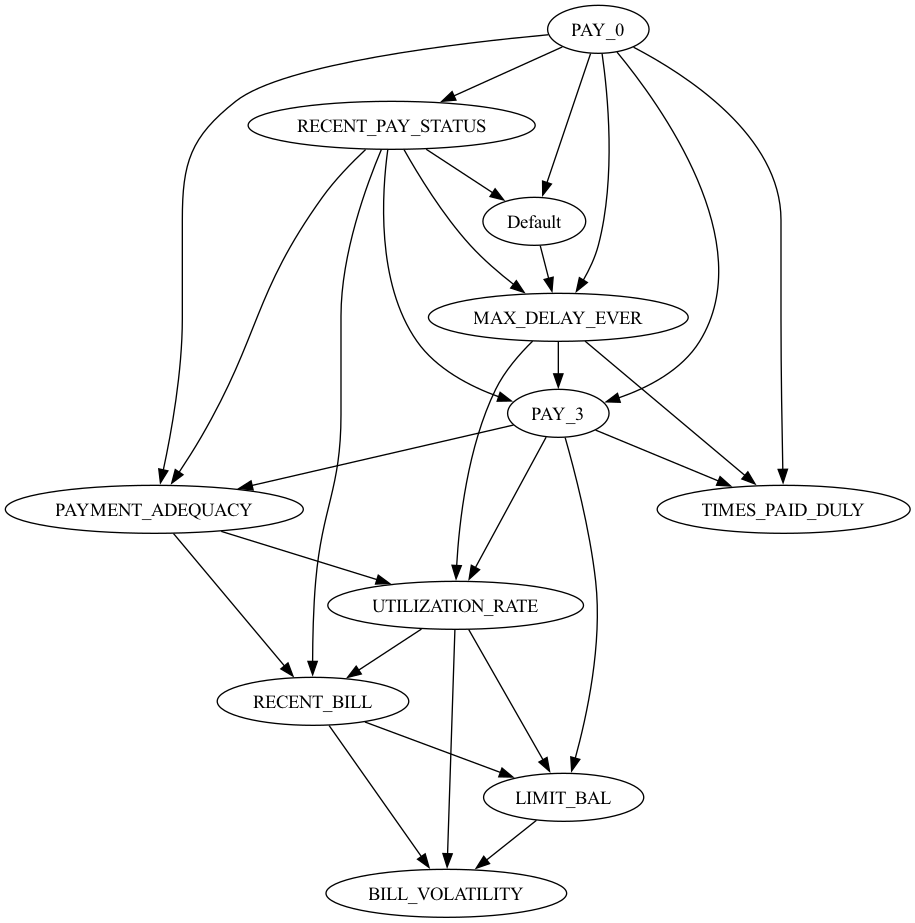

In [86]:
# Convert learned model into pygraphviz object
model_graphviz = estimated_model.to_graphviz()

# Save in multiple formats
model_graphviz.draw("learned_structure.png", prog="dot")
model_graphviz.draw("learned_structure.pdf", prog="dot")
model_graphviz.draw("learned_structure.svg", prog="dot")

# Verify files were created
import os, glob
print("cwd:", os.getcwd())
print("created:", glob.glob("learned_structure.*"))

# Display inline (Jupyter)
from IPython.display import Image, display
display(Image("learned_structure.png"))
